In [1]:
import pandas as pd

In [2]:
from datasets import load_dataset

In [3]:
import seaborn as sns
import ast
import matplotlib.pyplot as plt

In [4]:
dataset = load_dataset('lukebarousse/data_jobs')

df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [5]:
df_DS_US = df[(df['job_title_short']=='Data Scientist')&(df['job_country']=='United States')].copy()

In [6]:
company_median = df_DS_US.groupby('company_name')['salary_year_avg'].median()

In [7]:
company_median = company_median.sort_values(ascending=False).head(5)

company_median

company_name
ReServe                                        585000.0
East River Electric Power Cooperative, Inc.    537000.0
Big Lots                                       375000.0
GM Financial                                   375000.0
Lands End                                      375000.0
Name: salary_year_avg, dtype: float64

In [8]:
company_median = company_median.reset_index()

company_median

,company_name,salary_year_avg
0,ReServe,585000.0
1,"East River Electric Power Cooperative, Inc.",537000.0
2,Big Lots,375000.0
3,GM Financial,375000.0
4,Lands End,375000.0


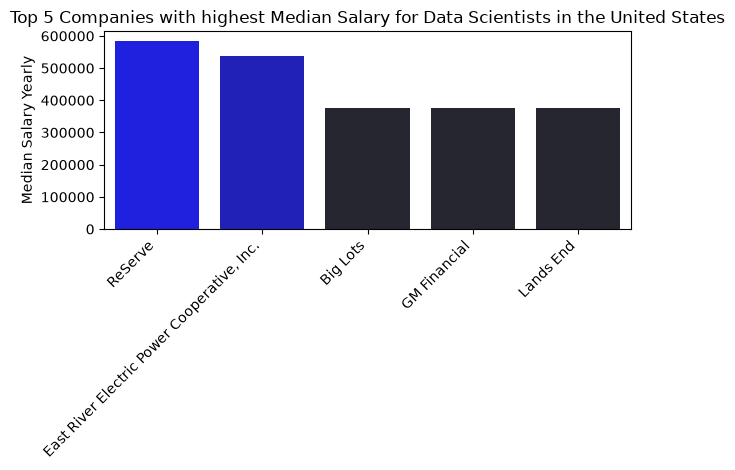

In [12]:
sns.barplot(company_median, x='company_name', y='salary_year_avg', hue='salary_year_avg', palette='dark:b')
plt.legend().set_visible(False)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Median Salary Yearly')
plt.title('Top 5 Companies with highest Median Salary for Data Scientists in the United States')
plt.tight_layout()


In [13]:
df_fil = df[(df['job_title_short']=='Data Scientist') & (df['job_country']=='United States')].dropna(subset=['salary_year_avg']).copy()

Text(0, 0.5, 'Number of Jobs')

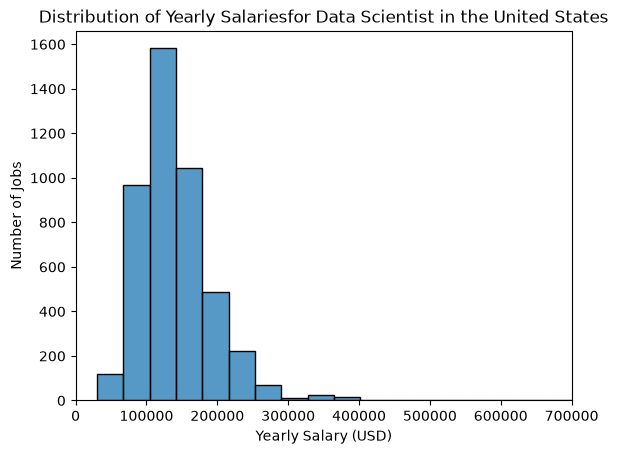

In [14]:
sns.histplot(df_fil, x='salary_year_avg',bins=25)
plt.xlim(0,700000)
plt.title('Distribution of Yearly Salariesfor Data Scientist in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')

In [15]:
job_titles = ['Data Analyst','Data Engineer', 'Data Scientist']

In [16]:
df_mod = df[(df['job_title_short'].isin(job_titles)) & (df['job_country']=='India')].dropna(subset=['salary_year_avg']).copy()

Text(0.5, 1.0, 'Yearly Salary Comparison for Data Roles in India')

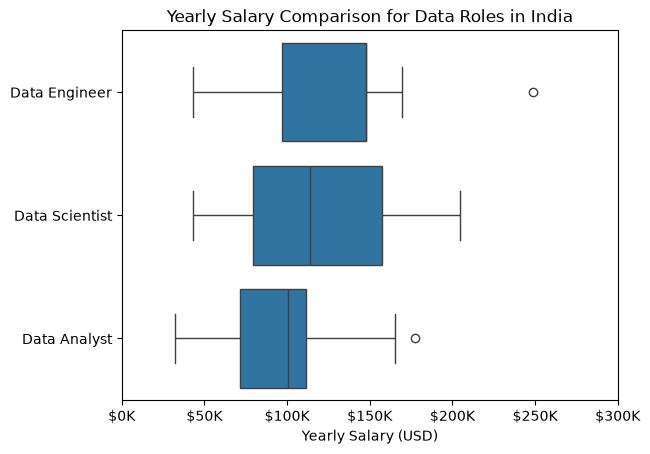

In [18]:
sns.boxplot(data=df_mod, x='salary_year_avg', y='job_title_short')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${int(x/1000)}K'))
plt.xlim(0,300000)
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.title('Yearly Salary Comparison for Data Roles in India')


In [20]:
df_DS = df[(df['job_title_short']=='Data Scientist') & (df['job_country']=='United States')].dropna(subset='salary_year_avg').copy()

<Axes: xlabel='job_country', ylabel='salary_year_avg'>

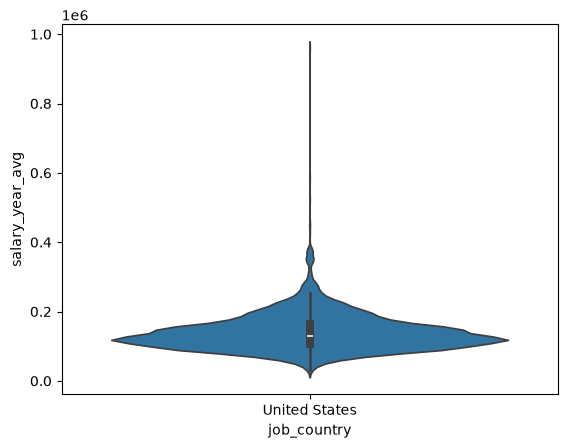

In [ ]:
sns.violinplot(data=df_DS, x='job_country', y='salary_year_avg')

(0.0, 450000.0)

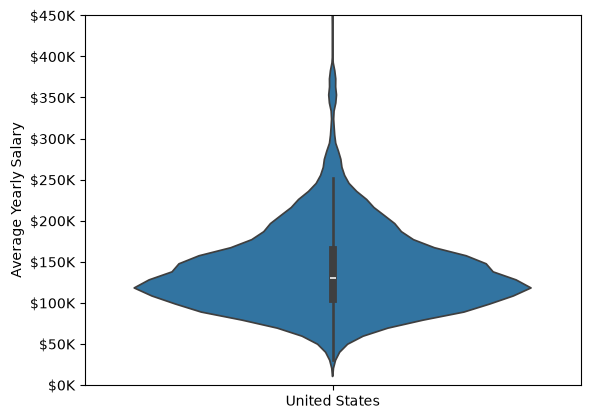

In [23]:
sns.violinplot(data=df_DS, x='job_country', y='salary_year_avg')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'${int(y/1000)}K'))
plt.ylabel('Average Yearly Salary')
plt.xlabel('')
plt.ylim(0,450000)